# Note-Aligned Two-Class Model and Behavior Choices

This notebook follows [the formulation note](../Documents/generated_notes/first_two_class_simulation_note.pdf) as the source of truth.
It is the compact notebook to understand the model before running the FCFS simulation.

## Sections
- 1. Working inputs
- 2. Core objects from the note
- 3. Available options for $b_i(\tau)$, $\phi_i(\tau,r)$, and $\xi_i(\tau)$
- 4. The selected profile used in the simulation notebook


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "appointment_simulation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for module_name in list(sys.modules):
    if module_name == "appointment_simulation" or module_name.startswith("appointment_simulation."):
        del sys.modules[module_name]

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from appointment_simulation import (
    BALKING_OPTIONS,
    CANCELLATION_OPTIONS,
    NO_SHOW_OPTIONS,
    behavior_option_frame,
    behavior_profile_frame,
    make_two_class_classes,
    model_setup_frame,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Working Inputs

Edit only this cell if you want to change the working mix $(\lambda, p)$ or the active behavior choices.
The three behavior families are kept explicit so the notebook stays close to the note.


In [2]:
TOTAL_LAMBDA = 0.24
CLASS_1_SHARE = 7 / 12
HORIZON_DAYS = 15

SELECTED_BALKING = "step_access"
SELECTED_CANCELLATION = "moderate"
SELECTED_NO_SHOW = "source_aligned"

CLASS_CONFIGS = make_two_class_classes(
    total_lambda=TOTAL_LAMBDA,
    class_1_share=CLASS_1_SHARE,
    balking_option=SELECTED_BALKING,
    cancellation_option=SELECTED_CANCELLATION,
    no_show_option=SELECTED_NO_SHOW,
)

MODEL_SETUP = model_setup_frame(
    total_lambda=TOTAL_LAMBDA,
    class_1_share=CLASS_1_SHARE,
    class_configs=CLASS_CONFIGS,
    balking_option=SELECTED_BALKING,
    cancellation_option=SELECTED_CANCELLATION,
    no_show_option=SELECTED_NO_SHOW,
)

display(MODEL_SETUP)


,class_id,label,lambda_total,p,lambda_i,b_i option,phi_i option,xi_i option,phi_base_i,phi_slope_i,phi_cap_i
0,1,MRI-like diagnostic,0.24,0.583333,0.14,step_access,moderate,source_aligned,0.01,0.008,0.12
1,2,Behavioral-health follow-up,0.24,0.583333,0.10,step_access,moderate,source_aligned,0.02,0.012,0.18


## 2. Core Objects From the Note

The note distinguishes clearly between the time index, the true calendar state, and the behavioral delay.

- $t = (D, s)$ is the decision epoch: current day $D$, current slot $s$
- $Y_t(r, m)$ is the rolling calendar state: day-ahead row $r$, slot-within-day column $m$
- $X_{i,r}^D$ is the derived day-start count: how many class-$i$ patients are scheduled for day $D+r$
- $\tau$ is the booking-time delay accepted by the patient, and it is the input to $b_i(\tau)$, $\phi_i(\tau,r)$, and $\xi_i(\tau)$
- demand is parameterized by total $\lambda$ and share $p$, with $\lambda_1 = p\lambda$ and $\lambda_2 = (1-p)\lambda$


## 3. Available Behavior Options

The next cells expose two realistic options for each family of functions. The classes stay different under each option, so the notebook is still clinically interpretable.


In [3]:
OPTION_TABLE = behavior_option_frame()


def profile_for_family(family: str, option_name: str) -> pd.DataFrame:
    """Build a behavior table while varying only one family of functions."""
    choices = {
        "balking_option": SELECTED_BALKING,
        "cancellation_option": SELECTED_CANCELLATION,
        "no_show_option": SELECTED_NO_SHOW,
    }
    family_to_key = {
        "balking": "balking_option",
        "cancellation": "cancellation_option",
        "no_show": "no_show_option",
    }
    choices[family_to_key[family]] = option_name
    classes = make_two_class_classes(
        total_lambda=TOTAL_LAMBDA,
        class_1_share=CLASS_1_SHARE,
        **choices,
    )
    frame = behavior_profile_frame(classes, horizon_days=HORIZON_DAYS).rename(
        columns={"tau_booked": "tau"}
    )
    frame["option"] = option_name
    return frame


def tau_slice(frame: pd.DataFrame) -> pd.DataFrame:
    """Keep one row per accepted delay when the behavior depends only on tau."""
    return (
        frame.loc[frame["residual_delay"] == frame["tau"]]
        .drop(columns=["residual_delay"])
        .drop_duplicates()
    )


def plot_tau_family_options(family: str, metric: str, title: str, ylabel: str) -> None:
    """Plot the two realistic options for one tau-based behavior family."""
    option_map = {
        "balking": BALKING_OPTIONS,
        "no_show": NO_SHOW_OPTIONS,
    }[family]
    plot_df = pd.concat(
        [tau_slice(profile_for_family(family, option_name)) for option_name in option_map],
        ignore_index=True,
    )
    labels = plot_df[["class_id", "label"]].drop_duplicates().sort_values("class_id")

    fig, axes = plt.subplots(1, len(labels), figsize=(13, 4), sharex=True, sharey=True)
    if len(labels) == 1:
        axes = [axes]

    for ax, (_, class_row) in zip(axes, labels.iterrows()):
        class_df = plot_df[plot_df["class_id"] == class_row["class_id"]]
        sns.lineplot(data=class_df, x="tau", y=metric, hue="option", marker="o", ax=ax)
        ax.set_title(class_row["label"])
        ax.set_xlabel(r"Accepted delay $\tau$ (days)")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1)
        ax.legend(title="option")

    fig.suptitle(title, y=1.05)
    plt.tight_layout()


def plot_cancellation_options(selected_taus: tuple[int, ...] = (3, 7, 14)) -> None:
    """Plot phi_i(tau, r) for the two realistic cancellation options."""
    tau_levels = [tau for tau in selected_taus if tau < HORIZON_DAYS]
    if not tau_levels:
        tau_levels = [HORIZON_DAYS - 1]

    plot_df = pd.concat(
        [profile_for_family("cancellation", option_name) for option_name in CANCELLATION_OPTIONS],
        ignore_index=True,
    )
    plot_df = plot_df.loc[plot_df["tau"].isin(tau_levels)].copy()
    plot_df["remaining_share"] = plot_df["residual_delay"] / plot_df["tau"]
    plot_df["appointment_proximity"] = 1 - plot_df["remaining_share"]
    plot_df["tau_label"] = plot_df["tau"].map(lambda tau: rf"$\tau={tau}$")
    labels = plot_df[["class_id", "label"]].drop_duplicates().sort_values("class_id")

    fig, axes = plt.subplots(
        len(CANCELLATION_OPTIONS),
        len(labels),
        figsize=(13, 7),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for row_index, option_name in enumerate(CANCELLATION_OPTIONS):
        for col_index, (_, class_row) in enumerate(labels.iterrows()):
            ax = axes[row_index, col_index]
            class_df = plot_df[
                (plot_df["class_id"] == class_row["class_id"])
                & (plot_df["option"] == option_name)
            ]
            sns.lineplot(
                data=class_df,
                x="appointment_proximity",
                y="daily_cancel_probability",
                hue="tau_label",
                marker="o",
                ax=ax,
            )
            option_title = option_name.replace("_", " ").title()
            ax.set_title(f"{class_row['label']} | {option_title}")
            ax.set_xlabel(r"Appointment proximity $1-r/\tau$")
            ax.set_ylabel("Daily cancellation probability")
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.legend(title=r"Booked delay $\tau$")

    fig.suptitle(r"Two realistic options for $\phi_i(\tau,r)$", y=1.02)
    plt.tight_layout()


def plot_cumulative_cancellation_options(selected_taus: tuple[int, ...] = (3, 7, 14)) -> None:
    """Plot the cumulative probability that the patient has already canceled."""
    tau_levels = [tau for tau in selected_taus if tau < HORIZON_DAYS]
    if not tau_levels:
        tau_levels = [HORIZON_DAYS - 1]

    plot_df = pd.concat(
        [profile_for_family("cancellation", option_name) for option_name in CANCELLATION_OPTIONS],
        ignore_index=True,
    )
    plot_df = plot_df.loc[plot_df["tau"].isin(tau_levels)].copy()
    plot_df["remaining_share"] = plot_df["residual_delay"] / plot_df["tau"]
    plot_df["appointment_proximity"] = 1 - plot_df["remaining_share"]
    plot_df["tau_label"] = plot_df["tau"].map(lambda tau: rf"$\tau={tau}$")
    labels = plot_df[["class_id", "label"]].drop_duplicates().sort_values("class_id")

    fig, axes = plt.subplots(
        len(CANCELLATION_OPTIONS),
        len(labels),
        figsize=(13, 7),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for row_index, option_name in enumerate(CANCELLATION_OPTIONS):
        for col_index, (_, class_row) in enumerate(labels.iterrows()):
            ax = axes[row_index, col_index]
            class_df = plot_df[
                (plot_df["class_id"] == class_row["class_id"])
                & (plot_df["option"] == option_name)
            ]
            sns.lineplot(
                data=class_df,
                x="appointment_proximity",
                y="cumulative_cancel_probability",
                hue="tau_label",
                marker="o",
                ax=ax,
            )
            option_title = option_name.replace("_", " ").title()
            ax.set_title(f"{class_row['label']} | {option_title}")
            ax.set_xlabel(r"Appointment proximity $1-r/\tau$")
            ax.set_ylabel("Probability already canceled")
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.legend(title=r"Booked delay $\tau$")

    fig.suptitle("Cumulative cancellation probability implied by the daily hazards", y=1.02)
    plt.tight_layout()


In [4]:
display(
    OPTION_TABLE.pivot_table(
        index=["family", "option", "description"],
        columns="label",
        values="details",
        aggfunc="first",
    )
)


label                                                                                                       Behavioral-health follow-up  \
family       option               description                                                                                             
balking      smooth_access        Smoother logistic balking when patients gradual...  logistic midpoint=12, slope=0.40, floor=0.04, ...   
             step_access          Step balking around a practical access threshol...             step threshold=14, low=0.04, high=0.72   
cancellation moderate             Moderate daily cancellation that rises with boo...               base=0.02, slope=0.012, ceiling=0.18   
             reschedule_heavy     Higher cancellation pressure, especially for pa...               base=0.03, slope=0.015, ceiling=0.24   
no_show      more_delay_sensitive A stronger delay effect to stress-test the feed...        gamma_0=0.18, gamma_max=0.62, sensitivity=6   
             source_aligned       Green-Savin style curves close to the literatur...        gamma_0=0.15, gamma_max=0.51, sensitivity=9   

label                                                                                                               MRI-like diagnostic  
family       option               description                                                                                            
balking      smooth_access        Smoother logistic balking when patients gradual...  logistic midpoint=18, slope=0.30, floor=0.02, ...  
             step_access          Step balking around a practical access threshol...             step threshold=21, low=0.02, high=0.55  
cancellation moderate             Moderate daily cancellation that rises with boo...               base=0.01, slope=0.008, ceiling=0.12  
             reschedule_heavy     Higher cancellation pressure, especially for pa...               base=0.02, slope=0.010, ceiling=0.16  
no_show      more_delay_sensitive A stronger delay effect to stress-test the feed...       gamma_0=0.02, gamma_max=0.38, sensitivity=28  
             source_aligned       Green-Savin style curves close to the literatur...       gamma_0=0.01, gamma_max=0.31, sensitivity=50

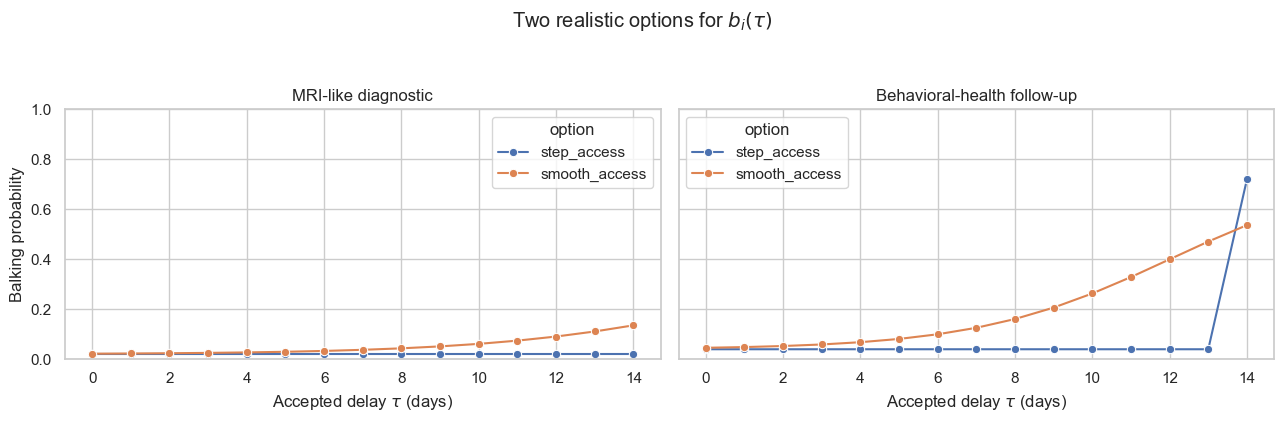

In [5]:
plot_tau_family_options(
    family="balking",
    metric="balk_probability",
    title=r"Two realistic options for $b_i(\tau)$",
    ylabel="Balking probability",
)


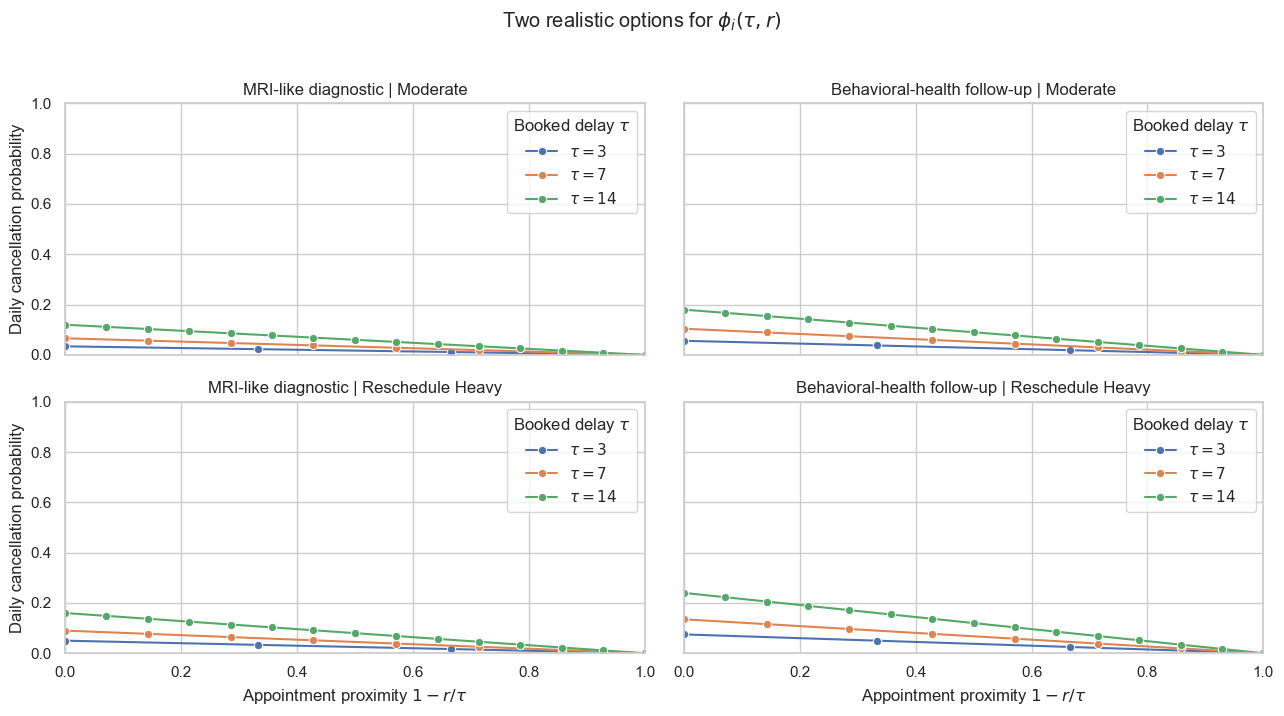

In [6]:
plot_cancellation_options()


### 3.1 Cumulative Cancellation Perspective

The daily curve $$\phi_i(\tau,r)$$ is the probability of canceling on that day, given that the patient is still on the schedule.

For intuition, it is also useful to plot the cumulative probability that the patient has already canceled by that point in the waiting process:

$$
P(\text{already canceled by residual delay } r) = 1 - \prod_{k=r+1}^{\tau} \left(1-\phi_i(\tau,k)\right).
$$

This is not a simple cumulative sum. Once a patient cancels, they leave the process, so the exact quantity is a survival-product calculation.


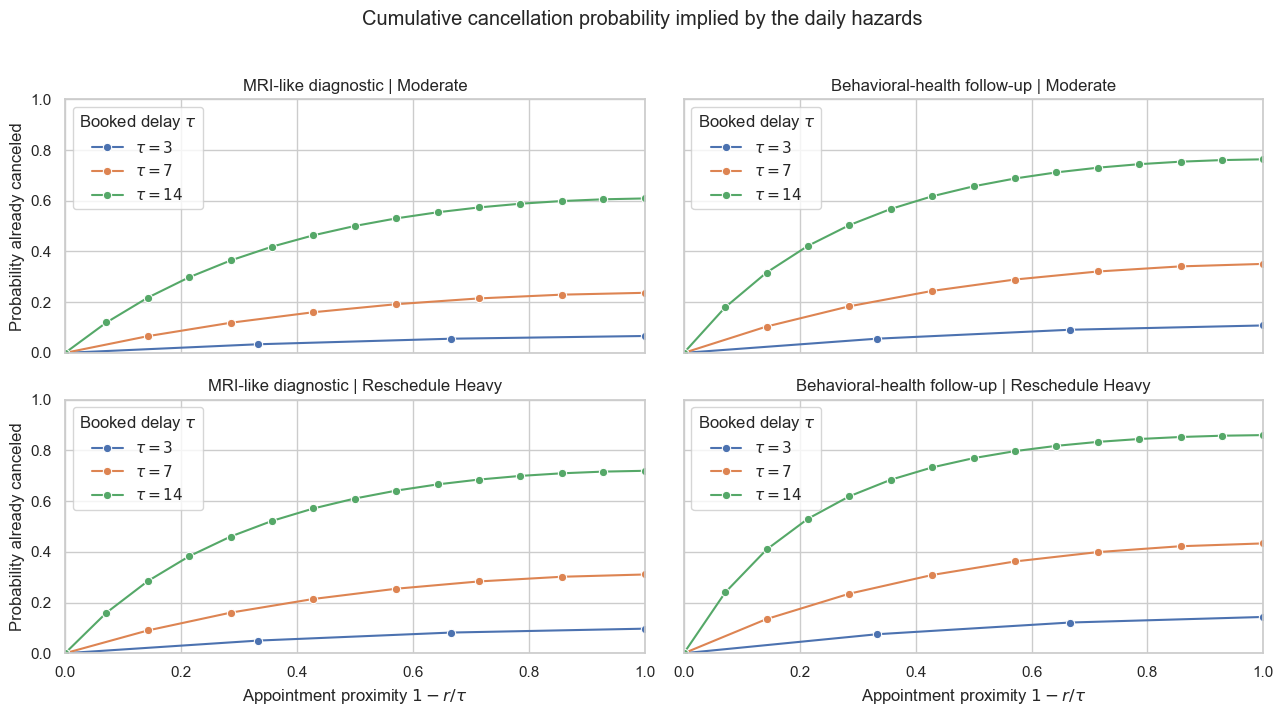

In [7]:
plot_cumulative_cancellation_options()


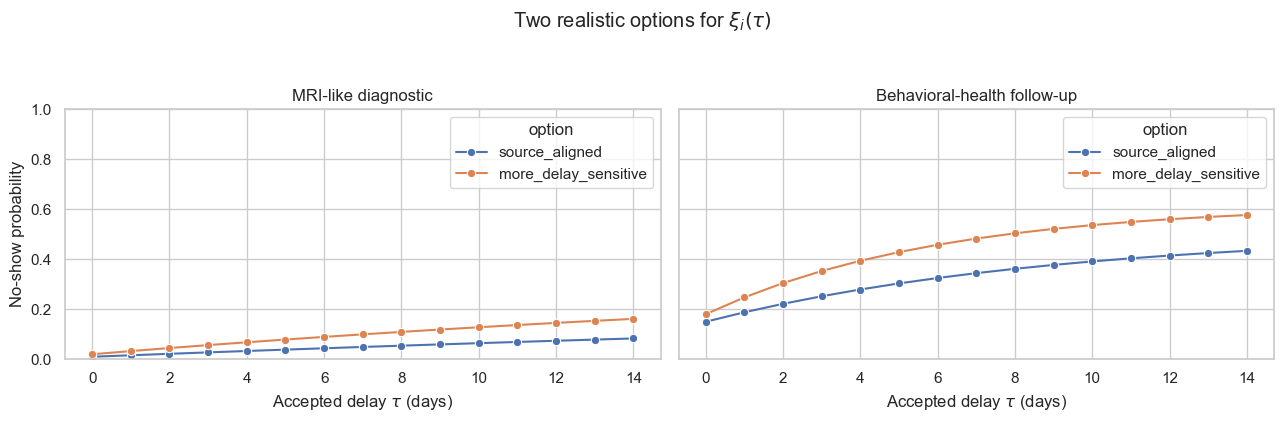

In [8]:
plot_tau_family_options(
    family="no_show",
    metric="no_show_probability",
    title=r"Two realistic options for $\xi_i(\tau)$",
    ylabel="No-show probability",
)


## 4. The Selected Profile Used in the FCFS Simulation Notebook

This is the one active profile used in the baseline FCFS simulation notebook. Change the three option names at the top if you want to study another combination.


In [9]:
SELECTED_PROFILE = behavior_profile_frame(CLASS_CONFIGS, horizon_days=HORIZON_DAYS).rename(
    columns={"tau_booked": "tau"}
)
SELECTED_TAU_PROFILE = tau_slice(SELECTED_PROFILE)
SELECTED_TAUS = [tau for tau in (3, 7, 14) if tau < HORIZON_DAYS]
if not SELECTED_TAUS:
    SELECTED_TAUS = [HORIZON_DAYS - 1]
SELECTED_CANCELLATION_SLICE = SELECTED_PROFILE.loc[
    SELECTED_PROFILE["tau"].isin(SELECTED_TAUS),
    ["class_id", "label", "tau", "residual_delay", "daily_cancel_probability", "cumulative_cancel_probability"],
].copy()
SELECTED_CANCELLATION_SLICE["remaining_share"] = (
    SELECTED_CANCELLATION_SLICE["residual_delay"] / SELECTED_CANCELLATION_SLICE["tau"]
)
SELECTED_CANCELLATION_SLICE["appointment_proximity"] = (
    1 - SELECTED_CANCELLATION_SLICE["remaining_share"]
)
SELECTED_CANCELLATION_SLICE["tau_label"] = SELECTED_CANCELLATION_SLICE["tau"].map(
    lambda tau: rf"$\tau={tau}$"
)

display(SELECTED_TAU_PROFILE.head(10))
display(SELECTED_CANCELLATION_SLICE.head(18))


,class_id,label,tau,balk_probability,no_show_probability,daily_cancel_probability,cumulative_cancel_probability
0,1,MRI-like diagnostic,0,0.02,0.010000,0.000,0.0
2,1,MRI-like diagnostic,1,0.02,0.015940,0.018,0.0
5,1,MRI-like diagnostic,2,0.02,0.021763,0.026,0.0
9,1,MRI-like diagnostic,3,0.02,0.027471,0.034,0.0
14,1,MRI-like diagnostic,4,0.02,0.033065,0.042,0.0
20,1,MRI-like diagnostic,5,0.02,0.038549,0.050,0.0
27,1,MRI-like diagnostic,6,0.02,0.043924,0.058,0.0
35,1,MRI-like diagnostic,7,0.02,0.049193,0.066,0.0
44,1,MRI-like diagnostic,8,0.02,0.054357,0.074,0.0
54,1,MRI-like diagnostic,9,0.02,0.059419,0.082,0.0


,class_id,label,tau,residual_delay,daily_cancel_probability,cumulative_cancel_probability,remaining_share,appointment_proximity,tau_label
6,1,MRI-like diagnostic,3,0,0.000000,0.066596,0.000000,1.000000,$\tau=3$
7,1,MRI-like diagnostic,3,1,0.011333,0.055896,0.333333,0.666667,$\tau=3$
8,1,MRI-like diagnostic,3,2,0.022667,0.034000,0.666667,0.333333,$\tau=3$
9,1,MRI-like diagnostic,3,3,0.034000,0.000000,1.000000,0.000000,$\tau=3$
28,1,MRI-like diagnostic,7,0,0.000000,0.236965,0.000000,1.000000,$\tau=7$
29,1,MRI-like diagnostic,7,1,0.009429,0.229702,0.142857,0.857143,$\tau=7$
30,1,MRI-like diagnostic,7,2,0.018857,0.214898,0.285714,0.714286,$\tau=7$
31,1,MRI-like diagnostic,7,3,0.028286,0.192044,0.428571,0.571429,$\tau=7$
32,1,MRI-like diagnostic,7,4,0.037714,0.160378,0.571429,0.428571,$\tau=7$
33,1,MRI-like diagnostic,7,5,0.047143,0.118838,0.714286,0.285714,$\tau=7$


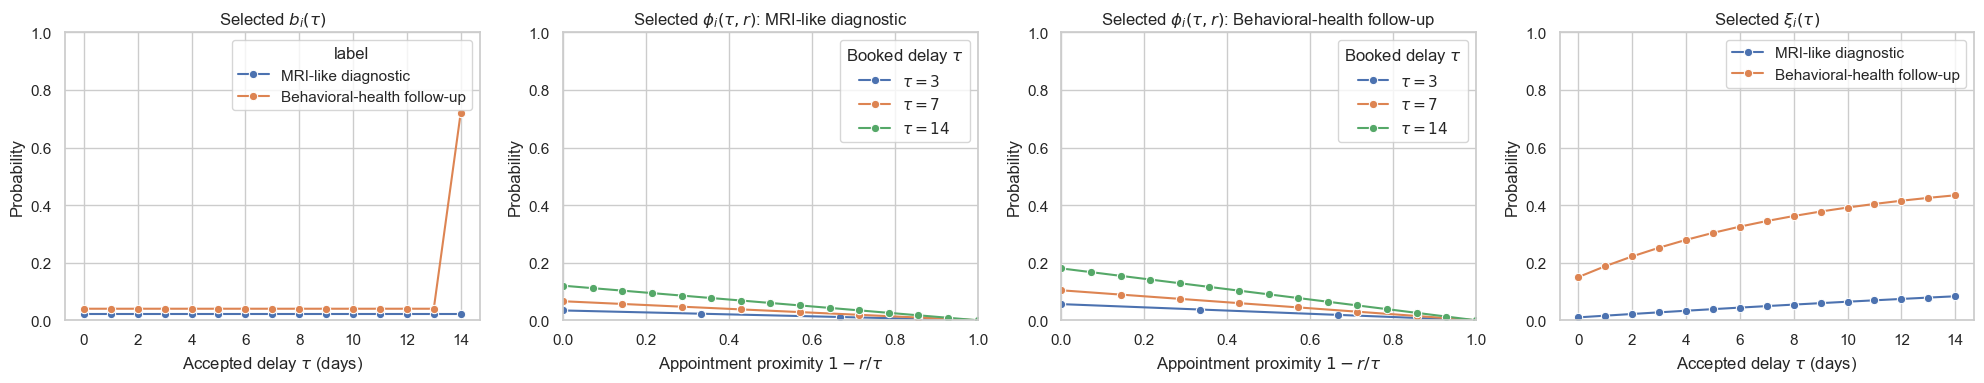

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

sns.lineplot(data=SELECTED_TAU_PROFILE, x="tau", y="balk_probability", hue="label", marker="o", ax=axes[0])
axes[0].set_title(r"Selected $b_i(\tau)$")
axes[0].set_xlabel(r"Accepted delay $\tau$ (days)")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 1)

for axis, class_id in zip(axes[1:3], (1, 2)):
    class_df = SELECTED_CANCELLATION_SLICE[SELECTED_CANCELLATION_SLICE["class_id"] == class_id]
    sns.lineplot(
        data=class_df,
        x="appointment_proximity",
        y="daily_cancel_probability",
        hue="tau_label",
        marker="o",
        ax=axis,
    )
    class_label = class_df["label"].iloc[0]
    axis.set_title(rf"Selected $\phi_i(\tau,r)$: {class_label}")
    axis.set_xlabel(r"Appointment proximity $1-r/\tau$")
    axis.set_ylabel("Probability")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.legend(title=r"Booked delay $\tau$")

sns.lineplot(data=SELECTED_TAU_PROFILE, x="tau", y="no_show_probability", hue="label", marker="o", ax=axes[3])
axes[3].set_title(r"Selected $\xi_i(\tau)$")
axes[3].set_xlabel(r"Accepted delay $\tau$ (days)")
axes[3].set_ylabel("Probability")
axes[3].set_ylim(0, 1)
axes[3].legend(title="")

plt.tight_layout()
